In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/Social_Media_Advertising.csv')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())
print(df.head())

(300000, 16)
Campaign_ID           int64
Target_Audience      object
Campaign_Goal        object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
Company              object
dtype: object
Campaign_ID         0
Target_Audience     0
Campaign_Goal       0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
Company             0
dtype: int64
         Campaign_ID  Conversion_Rate            ROI         Clicks  \
count  300000.000000    300000.000000  300000.000000  300000.000000   
mean   550444.8044

In [8]:
# --- Parse date ---
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Campaign_ID', 'Date']).reset_index(drop=True)

# --- Core performance features ---
df['CTR'] = df['Clicks'] / df['Impressions'].replace(0, np.nan)

df['Duration_Days'] = df['Duration'].str.extract(r'(\d+)').astype(float)
df['Acquisition_Cost_Clean'] = df['Acquisition_Cost'].replace(r'[\$,]', '', regex=True).astype(float)

# --- Campaign-level CTR baseline (early performance benchmark) ---
campaign_avg_ctr = df.groupby('Campaign_ID')['CTR'].transform('mean')
df['CTR_vs_Campaign_Avg'] = df['CTR'] / campaign_avg_ctr.replace(0, np.nan)

# --- Spend efficiency: Conversion per dollar ---
df['Spend_Efficiency'] = df['Conversion_Rate'] / df['Acquisition_Cost_Clean'].replace(0, np.nan)

# --- Engagement decay relative to campaign average ---
campaign_avg_eng = df.groupby('Campaign_ID')['Engagement_Score'].transform('mean')
df['Engagement_vs_Avg'] = df['Engagement_Score'] / campaign_avg_eng.replace(0, np.nan)

# --- ROI pressure ---
df['ROI_Clean'] = pd.to_numeric(df['ROI'], errors='coerce')
# ---  FATIGUE LABEL ---
# Loosen thresholds - fatigued if ANY two of three conditions are met

roi_threshold = df['ROI_Clean'].quantile(0.35)
ctr_low = df['CTR_vs_Campaign_Avg'] < 0.90
engagement_low = df['Engagement_vs_Avg'] < 0.90
roi_low = df['ROI_Clean'] < roi_threshold

# Fatigued if at least 2 conditions are true
df['Fatigued'] = ((ctr_low.astype(int) + 
                   engagement_low.astype(int) + 
                   roi_low.astype(int)) >= 2).astype(int)

print(df['Fatigued'].value_counts())
print(f"\nFatigue rate: {df['Fatigued'].mean()*100:.2f}%")

Fatigued
0    281985
1     18015
Name: count, dtype: int64

Fatigue rate: 6.00%


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

# --- Leakage-free feature set ---
# Remove ROI_Clean and Spend_Efficiency since they were used to build the label
features = [
    'CTR',
    'CTR_vs_Campaign_Avg',
    'Engagement_Score',
    'Engagement_vs_Avg',
    'Conversion_Rate',
    'Acquisition_Cost_Clean',
    'Duration_Days',
    'Clicks',
    'Impressions',
    'Channel_Used',
    'Target_Audience',
    'Campaign_Goal',
    'Customer_Segment'
]

df_model = df[features + ['Fatigued']].dropna()

# --- Encode categoricals ---
cat_cols = ['Channel_Used', 'Target_Audience', 'Campaign_Goal', 'Customer_Segment']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# --- Split ---
X = df_model[features]
y = df_model['Fatigued']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Retrain ---
scale = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

[0]	validation_0-auc:0.99186
[50]	validation_0-auc:0.99221
[100]	validation_0-auc:0.99235
[150]	validation_0-auc:0.99238
[200]	validation_0-auc:0.99241
[250]	validation_0-auc:0.99243
[299]	validation_0-auc:0.99248

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56397
           1       0.52      0.98      0.68      3603

    accuracy                           0.95     60000
   macro avg       0.76      0.96      0.83     60000
weighted avg       0.97      0.95      0.95     60000

ROC-AUC Score: 0.9925


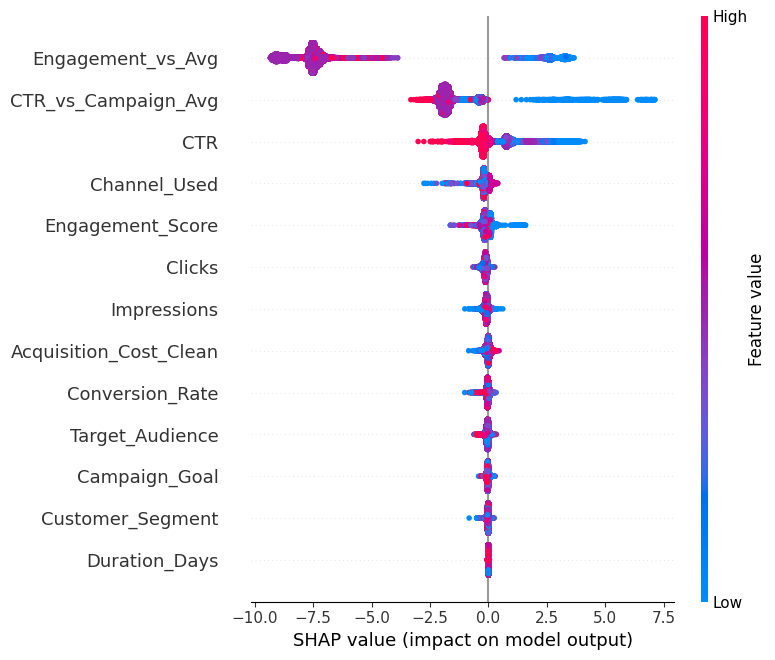

In [11]:
import shap

# --- SHAP explainer ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# --- Summary plot ---
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features, show=True)

In [13]:
import os
import pickle

# Create the folder if it doesn't exist
os.makedirs('../model', exist_ok=True)

# Save the model
with open('../model/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!


In [16]:
# Check exact encoding from training
for col in cat_cols:
    unique_vals = sorted(df[col].unique())
    for i, val in enumerate(unique_vals):
        print(f"{col}: '{val}' -> {i}")
    print()

Channel_Used: 'Facebook' -> 0
Channel_Used: 'Instagram' -> 1
Channel_Used: 'Pinterest' -> 2
Channel_Used: 'Twitter' -> 3

Target_Audience: 'All Ages' -> 0
Target_Audience: 'Men 18-24' -> 1
Target_Audience: 'Men 25-34' -> 2
Target_Audience: 'Men 35-44' -> 3
Target_Audience: 'Men 45-60' -> 4
Target_Audience: 'Women 18-24' -> 5
Target_Audience: 'Women 25-34' -> 6
Target_Audience: 'Women 35-44' -> 7
Target_Audience: 'Women 45-60' -> 8

Campaign_Goal: 'Brand Awareness' -> 0
Campaign_Goal: 'Increase Sales' -> 1
Campaign_Goal: 'Market Expansion' -> 2
Campaign_Goal: 'Product Launch' -> 3

Customer_Segment: 'Fashion' -> 0
Customer_Segment: 'Food' -> 1
Customer_Segment: 'Health' -> 2
Customer_Segment: 'Home' -> 3
Customer_Segment: 'Technology' -> 4



In [17]:
# Test with extreme fatigue scenario
test = pd.DataFrame([{
    'CTR': 0.001,
    'CTR_vs_Campaign_Avg': 0.50,
    'Engagement_Score': 1,
    'Engagement_vs_Avg': 0.50,
    'Conversion_Rate': 0.01,
    'Acquisition_Cost_Clean': 25.0,
    'Duration_Days': 30.0,
    'Clicks': 100,
    'Impressions': 100000,
    'Channel_Used': 0,
    'Target_Audience': 0,
    'Campaign_Goal': 0,
    'Customer_Segment': 0
}])

prob = model.predict_proba(test)[0][1]
print(f"Fatigue probability: {prob:.4f}")
print(f"Prediction at 0.3 threshold: {'FATIGUED' if prob >= 0.3 else 'HEALTHY'}")

Fatigue probability: 0.9965
Prediction at 0.3 threshold: FATIGUED
